In [ ]:
import numpy as np
import scipy as sp
import h5py

HBAR = 6.582119569e-16  # eV*s
REST_ENERGY_E = 0.51999895069e6  # eV
C = 2.997924580e18  # A/S
M_E = REST_ENERGY_E / (C**2)

material_data = {
    # --- Elemental Semiconductors ---
    "Si": {
        "a0": 5.43,
        "v_sym": {3: -1.43,   4: 0.0, 8: 0.27,  11: 0.545},
        "v_asym":  {3: 0,   4: 0.0, 8: 0.0,  11: 0.0},
        "lamda_sym": 0.0014422046,
        "lamda_asym": 0.0
    },
    "Ge": {
        "a0": 5.66,
        "v_sym": {3: -1.565,  4: 0.0, 8: 0.07,  11: 0.41},
        "v_asym":  {3: 0,  4: 0.0, 8: 0,  11: 0},
        "lamda_sym": 0.0078913083,
        "lamda_asym": 0.0
    },
}

# --- User Interface ---
name = "Si"  # Just change this to switch materials
USE_SOC = False
# ----------------------

# Automatic Assignment
data = material_data[name]
a_0 = data["a0"]
v_c = data["v_sym"]
v_a = data["v_asym"]
lambda_s = data["lamda_sym"]
lambda_a = data["lamda_asym"]
prefactor = 2 * np.pi / a_0

def get_energy(g_vec):

    # Using axis=-1 ensures it sums the squares across the last dimension
    g_sq = np.sum(g_vec**2, axis=-1)
    return (HBAR**2 * g_sq) / (2 * M_E)

def generate_g_vecs(e_cut=20.0):
    """
    Generates G-vectors and groups them into shells of identical magnitudes
    to avoid breaking crystal symmetries.
    """
    max_shell = e_cut * 2 * M_E / (HBAR**2) / (prefactor**2) # Convert energy cutoff to G^2 cutoff
    n_max = int(np.ceil(np.sqrt(max_shell)))  # Max integer index for G-vectors
    
    b1 = prefactor * np.array([-1, 1, 1])
    b2 = prefactor * np.array([1, -1, 1])
    b3 = prefactor * np.array([1, 1, -1]) 
    
    n_range = np.arange(-n_max, n_max + 1)
    
    h, k, l = np.meshgrid(n_range, n_range, n_range)
    g_array = (h[..., None] * b1 + k[..., None] * b2 + l[..., None] * b3).reshape(-1, 3)
                

    mags_squared = np.sum(g_array**2, axis=1)
    e_g = get_energy(g_array)
    mask = e_g <= e_cut

    g_vecs = g_array[mask]
    mags_filtered = mags_squared[mask]
    rounded_mags = np.round(mags_filtered, 5)
    # Identify unique shell radii
    unique_mags = np.unique(rounded_mags)
    
    shells = []
    total_g = 0
    for n,mag in enumerate(unique_mags):
        mask = np.isclose(rounded_mags, mag)
        shells.append(g_vecs[mask])
        total_g = total_g + len(g_vecs[mask])
        print(f"Shell {n}: G^2 = {mag:.5f}, new plane waves = {np.sum(mask)}, total plane waves = {total_g}")

    print(f"Generated {len(unique_mags)} shells and {total_g} G-vectors.")
    g_vecs = np.vstack(shells)  

    return g_vecs

G = generate_g_vecs(e_cut=55.0)

# q = G_i - G_j =  deltaG[i,j]
q = G[:, np.newaxis, :] - G[np.newaxis, :, :]

q_sq = np.sum(q**2, axis=-1)/ prefactor**2  # Dimensionless q^2 in units of (2pi/a_0)^2
tau = a_0/8 * np.array([1,1,1])

dot_q_tau = np.dot(q, tau)
phase_s = np.cos(dot_q_tau)
phase_a  = np.sin(dot_q_tau)

V_matrix = np.zeros_like(q_sq, dtype=np.complex128)

mask_3 = np.isclose(q_sq, 3.0)
mask_4 = np.isclose(q_sq, 4.0)
mask_8 = np.isclose(q_sq, 8.0)
mask_11 = np.isclose(q_sq, 11.0)

def apply_basis(mask, v_s, v_a):
    # This implements the formula: V = exp(iq.tau)*V_cat + exp(-iq.tau)*V_an
    return (2*phase_s[mask] * v_s + 1j *phase_a[mask] * v_a)

V_matrix[mask_3]  = apply_basis(mask_3, v_c[3], v_a[3])
V_matrix[mask_4]  = apply_basis(mask_4, v_c[4], v_a[4])
V_matrix[mask_8]  = apply_basis(mask_8, v_c[8], v_a[8])
V_matrix[mask_11] = apply_basis(mask_11, v_c[11], v_a[11])

SOC_prefactor = -1j * ((phase_s * lambda_s) + (1j * phase_a * lambda_a))

L_point = np.array([0.5, 0.5, 0.5]) * prefactor
Gamma_point = np.array([0.0, 0.0, 0.0]) * prefactor
X_point = np.array([1.0, 0.0, 0.0]) * prefactor

num_points = 20
k_path_L_G = np.linspace(L_point, Gamma_point, num_points)
# Path 2: Gamma to X (skip the first point to avoid duplicate Gamma)
k_path_G_X = np.linspace(Gamma_point, X_point, num_points)[1:]
k_path = np.vstack((k_path_L_G, k_path_G_X))

distances_L_G = -np.linalg.norm(k_path_L_G - Gamma_point, axis=1) / prefactor
distances_G_X = np.linalg.norm(k_path_G_X - Gamma_point, axis=1) / prefactor
k_dist = np.concatenate((distances_L_G, distances_G_X))

bands = []
for k_vec in k_path:
    # Calculate kinetic energy for this specific k
    # V_matrix is k-independent, so we only update T_matrix
    gpk = G + k_vec[np.newaxis, :]
    gpk_dimless = gpk / prefactor
    g_mags = np.linalg.norm(gpk, axis=1)
    T_matrix = np.diag((HBAR**2 * g_mags**2) / (2 * M_E))
    H_std = T_matrix + V_matrix

    if USE_SOC:
        # Build the 2N x 2N Matrix
        A = np.cross(gpk_dimless[:, np.newaxis, :], gpk_dimless[np.newaxis, :, :])
        A_x = A[..., 0]
        A_y = A[..., 1]
        A_z = A[..., 2]

        H_soc_up_up     = SOC_prefactor * A_z
        H_soc_down_down = -H_soc_up_up
        H_soc_up_down   = SOC_prefactor * (A_x - 1j * A_y)
        H_soc_down_up   = SOC_prefactor * (A_x + 1j * A_y)

        H_uu = H_std + H_soc_up_up
        H_dd = H_std + H_soc_down_down
        H_full = np.block([
            [H_uu,          H_soc_up_down],
            [H_soc_down_up, H_dd         ]
        ])

        # Solve and store the first 16 bands (spin-split)
        eigvals, _ = sp.linalg.eigh(H_full)
        bands.append(eigvals[0:16])
        
    else:
        # Solve the standard N x N Matrix
        eigvals, _ = sp.linalg.eigh(H_std)
        bands.append(eigvals[0:8])

bands = np.array(bands)

# Shift the Valence Band Maximum (VBM) to 0 eV
gamma_index = num_points - 1  # Index where k = 0
vbm_index = 7 if USE_SOC else 3  # VBM is the 8th band with SOC, 4th band without
vbm = bands[gamma_index, vbm_index]   
shifted_bands = bands - vbm

# Dynamic filename generation
state_label = "_SOC" if USE_SOC else ""
file_name = f"{name}{state_label}_bands.h5"

# 2. Save to HDF5
with h5py.File(file_name, 'w') as f:
    # Creating a group is good practice for organization

    # simulation (kpath, kdist, shifted bands), simulation_2 () 
    group = f.create_group("simulation")
    
    # Store the datasets
    group.create_dataset("k_path", data=k_path)
    group.create_dataset("k_dist", data=k_dist)
    group.create_dataset("energies", data=shifted_bands)
    
    # Add attributes (metadata) - this is why h5 is better than txt!
    group.attrs["unit"] = "electron_volt"
    group.attrs["label"] = "L to Gamma to X"

print(f"Data successfully saved to {file_name}")

Shell 0: G^2 = 0.00000, new plane waves = 1, total plane waves = 1
Shell 1: G^2 = 4.01681, new plane waves = 8, total plane waves = 9
Shell 2: G^2 = 5.35575, new plane waves = 6, total plane waves = 15
Shell 3: G^2 = 10.71149, new plane waves = 12, total plane waves = 27
Generated 4 shells and 27 G-vectors.
Data successfully saved to Si_bands.h5


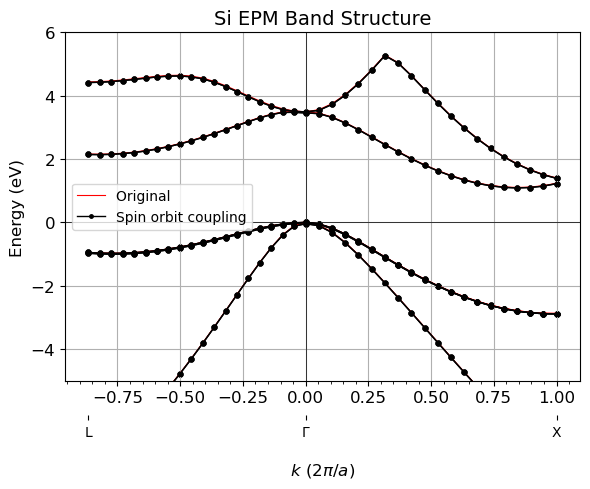

In [72]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
name = "Si" 

with h5py.File(name+"_bands.h5", 'r') as f:
    y = f["simulation/energies"][:]
    x = f["simulation/k_dist"][:] 
    
with h5py.File(name+"_SOC_bands.h5", 'r') as f:
    ysoc = f["simulation/energies"][:]
    xsoc = f["simulation/k_dist"][:] 

#-------User Interface---------
          #name of the crystal for the title
y_min=-5                   #minimum y-value on graph
y_max=6                    #maximum y-value on graph
#------------------------------


plt.figure(figsize=(6, 5))
for i in range(y.shape[1]-2):
    # Add labels only on the first iteration (i == 0)
    label_cb = "Original " if i == 0 else ""

    # Black data
    plt.plot(x, y[:, i], color='red', linewidth=0.8, label=label_cb)
for i in range(ysoc.shape[1]-4):
    # Add labels only on the first iteration (i == 0)
    label_soc = "Spin orbit coupling" if i == 0 else ""

    # Red data
    plt.scatter(xsoc, ysoc[:, i], color='black', marker='.', s=50)
    plt.plot(xsoc, ysoc[:, i], color='black', marker='.', markersize=5, linewidth=1, label=label_soc)

plt.axvline(0, color='black', linewidth=0.5) 
plt.axhline(0, color='black', linewidth=0.5) 
#plt.xlim(x[0], x[-1])
plt.ylim(y_min, y_max) 
ax = plt.gca()

# 1. Primary Axis: Numerical Values
# We don't pass labels here, just let Matplotlib handle the numbers
ax.set_xticks([x[0], 0, x[-1]]) # Ensure the main bounds are marked
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10)) # Increase density
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis='both', which='major', labelsize=12)

# 2. Secondary Axis: Symmetry Labels
# We place this at the bottom but "outward" so it sits below the numbers
secax = ax.secondary_xaxis('bottom', functions=(lambda x: x, lambda x: x))
secax.set_xticks([x[0], 0, x[-1]])
secax.set_xticklabels(['L', r'$\Gamma$', 'X'], fontsize=14, fontweight='bold')

# Disabling the "line" for the secondary axis makes the letters look like 
# they belong to the main axis rather than a second box
secax.spines['bottom'].set_visible(False)
secax.spines['bottom'].set_position(('outward', 25))
plt.yticks(fontsize=12)
plt.ylabel(r'Energy (eV)', fontsize=12)
plt.xlabel(r'$k \ (2\pi/a)$', fontsize=12, labelpad=40) # Push label down
plt.title('%s EPM Band Structure' %name, fontsize=14)
plt.tight_layout()
plt.grid(True)
plt.legend()
#plt.savefig(f"{name}_bands.png", dpi=300)
plt.show()

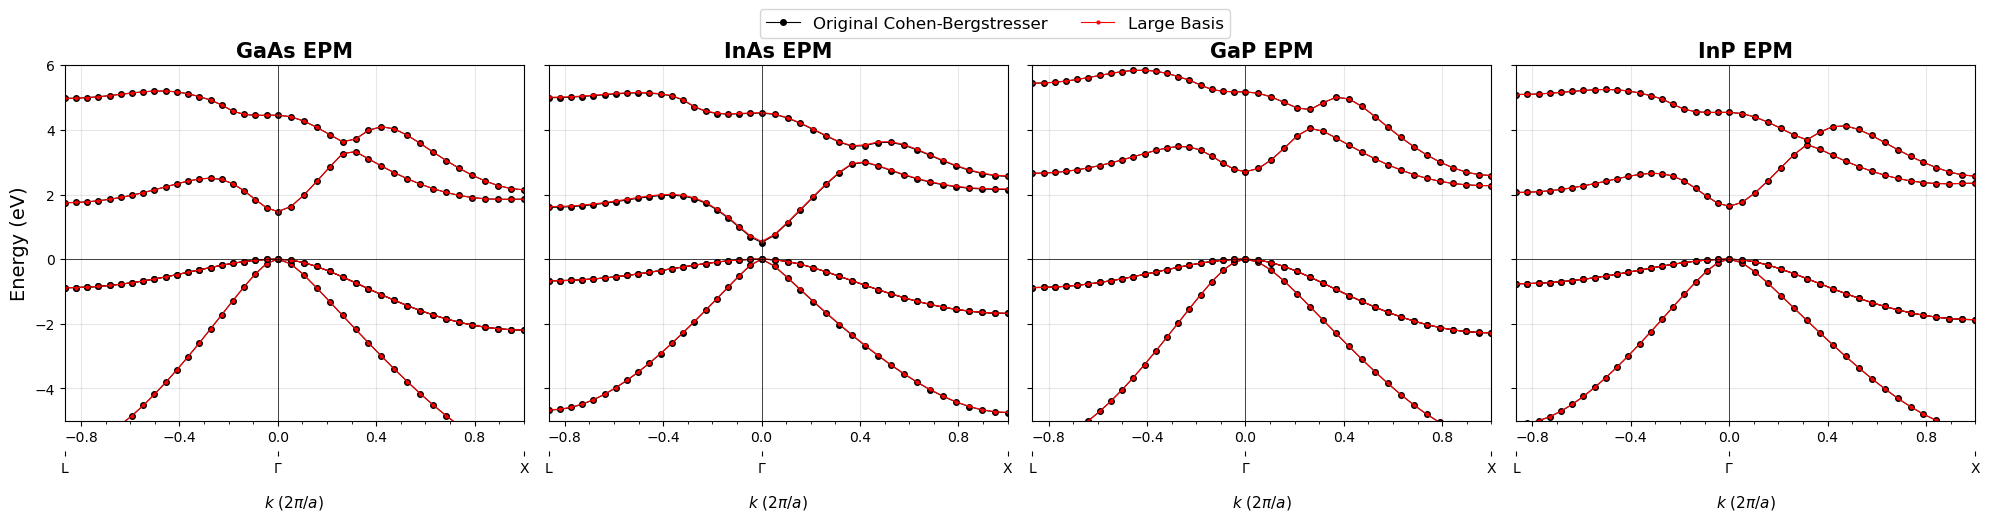

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import h5py

names = ["GaAs", "InAs", "GaP", "InP"]
y_min, y_max = -5, 6

# Create a figure with 1 row and 4 columns
# sharey=True makes comparison easier between different materials
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for idx, name in enumerate(names):
    ax = axes[idx]
    
    # Load data for current crystal
    with h5py.File(f"{name}_bands.h5", 'r') as f:
        y = f["simulation/energies"][:]
        x = f["simulation/k_dist"][:] 
    with h5py.File(f"{name}_lb_bands.h5", 'r') as f:
        ylb = f["simulation/energies"][:]
        xlb = f["simulation/k_dist"][:] 

    # Plot the 6 bands
    for i in range(6):
        # We only need labels for the very first plot's first line to build the legend
        label_cb = "Original Cohen-Bergstresser" if (idx == 0 and i == 0) else ""
        label_lb = "Large Basis" if (idx == 0 and i == 0) else ""

        # Black data (Cohen-Bergstresser)
        ax.plot(x, y[:, i], color='black', marker='.', markersize=8, linewidth=0.8, label=label_cb)
        
        # Red data (Large Basis)
        ax.plot(xlb, ylb[:, i], color='red', marker='.', markersize=4, linewidth=0.8, label=label_lb)

    # --- Axis Styling ---
    ax.axvline(0, color='black', linewidth=0.5) 
    ax.axhline(0, color='black', linewidth=0.5) 
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(y_min, y_max)
    ax.set_title(f'{name} EPM', fontsize=15, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # 1. Primary Axis (Numbers)
    ax.set_xticks([x[0], 0, x[-1]])
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5)) # Fewer bins for crowded plots
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    
    # 2. Secondary Axis (Symmetry Labels)
    secax = ax.secondary_xaxis('bottom', functions=(lambda x: x, lambda x: x))
    secax.set_xticks([x[0], 0, x[-1]])
    secax.set_xticklabels(['L', r'$\Gamma$', 'X'], fontsize=12, fontweight='bold')
    secax.spines['bottom'].set_visible(False)
    secax.spines['bottom'].set_position(('outward', 22))

    # Only show Y-label on the first plot
    if idx == 0:
        ax.set_ylabel(r'Energy (eV)', fontsize=14)
    
    ax.set_xlabel(r'$k \ (2\pi/a)$', fontsize=11, labelpad=35)

# Add one global legend at the top
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, fontsize=12)

plt.tight_layout()
plt.savefig("all_bands.png", dpi=300, bbox_inches='tight')
plt.show()

Total shells generated: 100
plane waves: 9 Largest G: [1. 1. 1.]  Energy_gamma: 0.00 Energy_x: -2.41
plane waves: 15 Largest G: [2. 2. 2.]  Energy_gamma: 3.22 Energy_x: 1.04
plane waves: 27 Largest G: [2. 2. 2.]  Energy_gamma: 3.47 Energy_x: 1.09
plane waves: 51 Largest G: [3. 3. 3.]  Energy_gamma: 3.58 Energy_x: 1.20
plane waves: 59 Largest G: [3. 3. 3.]  Energy_gamma: 3.41 Energy_x: 0.94
plane waves: 65 Largest G: [4. 4. 4.]  Energy_gamma: 3.36 Energy_x: 0.85
plane waves: 89 Largest G: [4. 4. 4.]  Energy_gamma: 3.40 Energy_x: 0.89
plane waves: 113 Largest G: [4. 4. 4.]  Energy_gamma: 3.44 Energy_x: 0.94
plane waves: 137 Largest G: [4. 4. 4.]  Energy_gamma: 3.43 Energy_x: 0.93


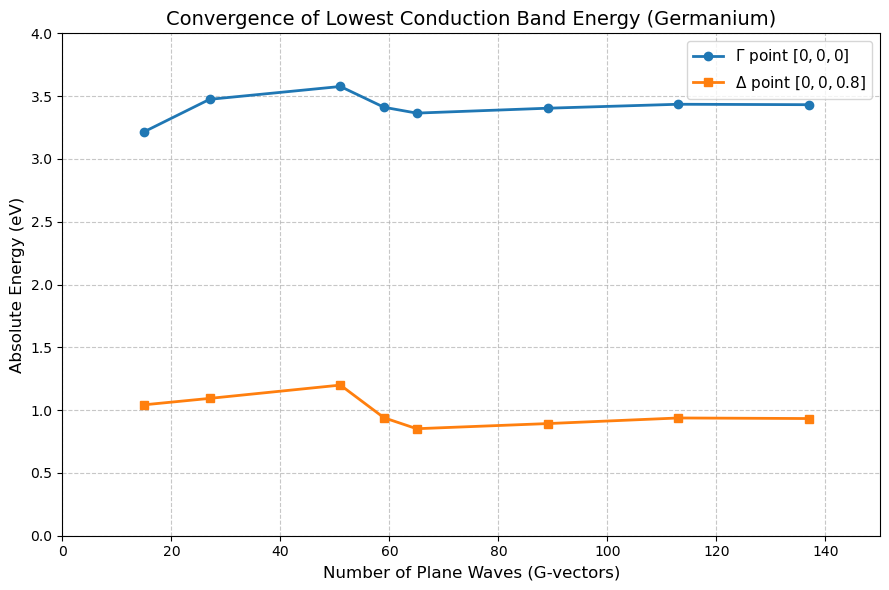

In [3]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

#-----User Interface-----
a_si = 5.43               # Lattice constant in Angstroms (Note: updated variable name from a_ge to a_si)
v3 = -1.43                # form factor for vectors of magnitude squared 3
v8 = 0.27                 # form factor for vectors of magnitude squared 8
v11 = 0.54                # form factor for vectors of magnitude squared 11
max_shells = 10           # Number of reciprocal space shells to include in the convergence test
#------------------------

HBAR = 6.582119569e-16           # eV*s
REST_ENERGY_E = 0.51999895069e6  # eV
C = 2.997924580e18               # A/S
M_E = REST_ENERGY_E / (C**2)
prefactor = 2 * np.pi / a_si

def generate_and_group_g_shells(n_max=6):
    """
    Generates G-vectors and groups them into shells of identical magnitudes
    to avoid breaking crystal symmetries.
    """
    b1 = prefactor * np.array([-1, 1, 1])
    b2 = prefactor * np.array([1, -1, 1])
    b3 = prefactor * np.array([1, 1, -1]) 
    
    n_range = np.arange(-n_max, n_max + 1)
    
    g_list = []
    for h in n_range:
        for k in n_range:
            for l in n_range:
                g = h*b1 + k*b2 + l*b3
                g_list.append(g)
                
    g_array = np.array(g_list)
    
    # Calculate magnitudes and round slightly to handle floating point noise
    mags = np.linalg.norm(g_array, axis=1)
    rounded_mags = np.round(mags, 5)

    # Identify unique shell radii
    unique_mags = np.unique(rounded_mags)
    
    shells = []
    for mag in unique_mags:
        mask = np.isclose(rounded_mags, mag)
        shells.append(g_array[mask])
        
    return shells


# 1. Generate shells of G-vectors
g_shells = generate_and_group_g_shells(n_max=6)\

print(f"Total shells generated: {len(g_shells)}")

# 2. Define the exact points in reciprocal space to evaluate
gamma_k = np.array([0.0, 0.0, 0.0]) * prefactor
delta_k = np.array([0.0, 0.0, 0.8]) * prefactor

# Tracking arrays for the convergence plot
num_pw_history = []
gamma_cb_energies = []
delta_cb_energies = []

# Initialize with the 0th shell (just the origin [0,0,0])
current_g = g_shells[0]

# 3. Iteratively add shells and solve the Hamiltonian
# We start the loop at 1 to add the next shell, ensuring we have enough basis 
# vectors to reliably calculate the 5th band (index 4)
for i in range(1, min(max_shells, len(g_shells))):
    current_g = np.vstack((current_g, g_shells[i]))

    num_pw = len(current_g)
    if num_pw <= 4:
        continue
        
    num_pw_history.append(num_pw)
    
    # Build V_matrix for the current basis set
    q = current_g[:, np.newaxis, :] - current_g[np.newaxis, :, :]
    G_squared_unit = prefactor**2
    q_sq = np.sum(q**2, axis=-1) / G_squared_unit
    
    tau = (a_si / 8) * np.array([1, 1, 1])
    V_matrix = np.zeros_like(q_sq, dtype=float)
    
    S_q = 2 * np.cos(np.dot(q, tau))
    
    V_matrix[np.isclose(q_sq, 3.0)] = v3 * S_q[np.isclose(q_sq, 3.0)]
    V_matrix[np.isclose(q_sq, 8.0)] = v8 * S_q[np.isclose(q_sq, 8.0)]
    V_matrix[np.isclose(q_sq, 11.0)] = v11 * S_q[np.isclose(q_sq, 11.0)]
    
    # --- Solve at Gamma Point ---
    gpk_gamma = current_g + gamma_k
    g_mags_gamma = np.linalg.norm(gpk_gamma, axis=1)
    T_gamma = np.diag((HBAR**2 * g_mags_gamma**2) / (2 * M_E))
    H_gamma = T_gamma + V_matrix

    eigvals_gamma, _ = sp.linalg.eigh(H_gamma)
    
    # dynamically find the Valence Band Maximum (Index 3 at Gamma)
    vbm = eigvals_gamma[3]
    
    # Store the lowest Conduction Band (Index 4) RELATIVE to the VBM
    gamma_cb_energies.append(eigvals_gamma[4] - vbm)
    
    # --- Solve at [0, 0, 0.8] Point ---
    gpk_delta = current_g + delta_k
    g_mags_delta = np.linalg.norm(gpk_delta, axis=1)
    T_delta = np.diag((HBAR**2 * g_mags_delta**2) / (2 * M_E))
    H_delta = T_delta + V_matrix
    eigvals_delta, _ = sp.linalg.eigh(H_delta)
    delta_cb_energies.append(eigvals_delta[4] - vbm)
    
    print(f"plane waves: {num_pw} Largest G: {np.max(current_g,0) / prefactor}  Energy_gamma: {(eigvals_gamma[4] - vbm):.2f} Energy_x: {(eigvals_delta[4] - vbm):.2f}")
    # Store the 5th state RELATIVE to the same VBM


# 4. Plotting the Convergence
plt.figure(figsize=(9, 6))

plt.plot(num_pw_history[1:], gamma_cb_energies[1:], marker='o', linewidth=2, label=r'$\Gamma$ point $[0, 0, 0]$')
plt.plot(num_pw_history[1:], delta_cb_energies[1:], marker='s', linewidth=2, label=r'$\Delta$ point $[0, 0, 0.8]$')

plt.title('Convergence of Lowest Conduction Band Energy (Germanium)', fontsize=14)
plt.xlabel('Number of Plane Waves (G-vectors)', fontsize=12)
plt.ylabel('Absolute Energy (eV)', fontsize=12)
plt.ylim(0,4)
plt.xlim(0,150)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()